# PointNet for MARS

A recording contains a time sequence of radar frames. The raw MATLAB array is `radar_data_cropped` with shape `(8, total_points)`: columns are detected radar points across the full recording, row 0 is the frame id used to group points into time frames, rows 2-6 are the model input features, and row 7 is timestamp-like metadata.

We write the model dimensions as:
- T: amount of time frames per training window
- D: amount of model input features (5 features: x, y, z, Doppler velocity, intensity)
- N: amount of point slots per frame (set to 64, the max observed in MARS raw frames)
- B: amount of batches

The model input tensor is `(B, T, N, D)`. MARS has 10 movement classes, 4 subjects, and 39 usable class recordings because `subject4` is missing `Right_limb_extension` / `radar_data10.mat`.

In [62]:
from functools import lru_cache
from pathlib import Path
import time
import pandas as pd

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from IPython.display import clear_output
from torch.utils.data import DataLoader, Dataset

In [63]:
PROJECT_ROOT = Path('/Users/elo/Coding/radar_ml')
DATA_ROOT = PROJECT_ROOT / 'datasets' / 'MARS'
CHECKPOINT_ROOT = PROJECT_ROOT / 'checkpoints' / 'MARS'

ACTIVITY_CLASS_NAMES = (
    'Left_upper_limb_extension', 'Right_upper_limb_extension',
    'Both_upper_limb_extension', 'Left_front_lunge',
    'Right_front_lunge', 'Squad', 'Left_side_lunge',
    'Right_side_lunge', 'Left_limb_extension', 'Right_limb_extension',
)
ACTIVITY_INDEX = {name: idx for idx, name in enumerate(ACTIVITY_CLASS_NAMES)}

DEVICE = "mps"
CONFIG = {
    'mat_key': 'radar_data_cropped',
    'frame_row': 0,
    'feature_names': ('x', 'y', 'z', 'velocity', 'intensity'),
    'feature_rows': (2, 3, 4, 5, 6),
    'feature_amount': 5,
    'frame_count': 60,
    'stride_frame_count': 60,
    'points_per_frame': 64,
    'validation_subject': 'subject3',
    'test_subject': 'subject4',
    'normalized_feature_clip': 4.0,
    'head_amount': 8,
    'batch_size': 16,
    'num_epochs': 10,
    'base_lr': 1e-3,
    'lr_warmup_epochs': 5,
    'adam_momentum': 0.9,
    'lr_decay_step': 20,
    'lr_decay_gamma': 0.5,
    'accum_iter': 1,
}

In [64]:
print(f'Classes: {len(ACTIVITY_CLASS_NAMES)}')
print(f'Input shape convention: (B, T={CONFIG["frame_count"]}, N={CONFIG["points_per_frame"]}, D={CONFIG["feature_amount"]})')
print(dict(zip(CONFIG['feature_names'], CONFIG['feature_rows'])))

Classes: 10
Input shape convention: (B, T=60, N=64, D=5)
{'x': 2, 'y': 3, 'z': 4, 'velocity': 5, 'intensity': 6}


# Data

In [65]:
@lru_cache(maxsize=None)
def load_mars_file_raw(file_path):
    "Helper to load one MARS `.mat` file and return raw frames from it."
    with h5py.File(file_path, 'r') as handle:
        radar = np.asarray(handle[CONFIG['mat_key']])

    frame_ids = radar[CONFIG['frame_row']].astype(np.int64)
    features = radar[list(CONFIG['feature_rows'])].T.astype(np.float32)

    frames = []
    for frame_id in np.unique(frame_ids):
        frames.append(torch.from_numpy(features[frame_ids == frame_id]))
    return frames

In [66]:
@lru_cache(maxsize=None)
def train_normalization_stats():
    "Compute normalization stats over the training subjects." 
    all_points = []
    for class_name in ACTIVITY_CLASS_NAMES:
        for file_path in sorted((DATA_ROOT / class_name).glob('subject*/radar_data*.mat')):
            subject = file_path.parent.name
            if subject in (CONFIG['validation_subject'], CONFIG['test_subject']):
                continue
            frames = load_mars_file_raw(str(file_path))
            all_points.append(torch.cat(frames, dim=0))
    all_points = torch.cat(all_points, dim=0)
    mean = all_points.mean(dim=0)
    std = all_points.std(dim=0).clamp_min(1e-6)
    return mean, std

In [67]:
@lru_cache(maxsize=None)
def load_mars_file(file_path):
    "Helper to load one MARS `.mat` file and return normalized frames." 
    mean, std = train_normalization_stats()
    frames = load_mars_file_raw(file_path)
    return [(frame - mean) / std for frame in frames]

In [ ]:
sample_file = next(
    file_path
    for class_name in ACTIVITY_CLASS_NAMES
    for file_path in sorted((DATA_ROOT / class_name).glob('subject*/radar_data*.mat'))
    if file_path.parent.name not in (CONFIG['validation_subject'], CONFIG['test_subject'])
)
frames = load_mars_file(str(sample_file))
print(sample_file)
print(len(frames))
print(frames[0].shape) # (points_in_frame, feature_amount)

In [69]:
def build_window_index(file_paths):
    "Creates window indexes of length frame_count offset by stride_frame_count."
    samples = []

    for file_path in file_paths:
        class_name = Path(file_path).parents[1].name
        frames = load_mars_file(str(file_path))
        max_start = len(frames) - CONFIG['frame_count']
        for start_idx in range(0, max_start + 1, CONFIG['stride_frame_count']):
            samples.append((str(file_path), start_idx, ACTIVITY_INDEX[class_name]))
    return samples

In [70]:
@lru_cache(maxsize=None)
def split_train_val_file_paths():
    "Split MARS recordings by subject so windows from one person do not leak across splits." 
    train_files = []
    val_files = []
    for class_name in ACTIVITY_CLASS_NAMES:
        for file_path in sorted((DATA_ROOT / class_name).glob('subject*/radar_data*.mat')):
            subject = file_path.parent.name
            if subject == CONFIG['test_subject']:
                continue
            if subject == CONFIG['validation_subject']:
                val_files.append(str(file_path))
            else:
                train_files.append(str(file_path))
    return train_files, val_files

In [71]:
def test_file_paths():
    "Return test recordings for the configured held-out subject." 
    return [
        str(file_path)
        for class_name in ACTIVITY_CLASS_NAMES
        for file_path in sorted((DATA_ROOT / class_name / CONFIG['test_subject']).glob('radar_data*.mat'))
    ]

In [ ]:
train_files, valid_files = split_train_val_file_paths()
train_windows = build_window_index(train_files)
valid_windows = build_window_index(valid_files)
print(f'Train windows: {len(train_windows)}')
print(f'Validation windows: {len(valid_windows)}')
print(train_windows[:5])

In [73]:
def process_frame(points):
    "Keep the same point slots in order across a window, padding with zeros if needed."
    points = torch.as_tensor(points, dtype=torch.float32)
    points = points.clamp(-CONFIG['normalized_feature_clip'], CONFIG['normalized_feature_clip'])

    if len(points) >= CONFIG['points_per_frame']:
        return points[:CONFIG['points_per_frame']]

    padded = torch.zeros((CONFIG['points_per_frame'], CONFIG['feature_amount']), dtype=torch.float32)
    padded[:len(points)] = points
    return padded

In [74]:
processed_frame = process_frame(frames[0])
print(processed_frame.shape)

torch.Size([64, 5])


In [75]:
class MARSDataset(Dataset):
    "Dataset containing MARS radar frame windows."
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, start_idx, label_idx = self.samples[idx]
        frames = load_mars_file(file_path)
        window = frames[start_idx:start_idx + CONFIG['frame_count']]

        processed_frames = [process_frame(frame) for frame in window]
        sequence = torch.stack(processed_frames, dim=0)
        label = torch.tensor(label_idx, dtype=torch.long)
        return sequence, label

In [76]:
train_data = MARSDataset(train_windows)
print(len(train_data))
x, y = train_data[0]
print(x.shape, y)

383
torch.Size([60, 64, 5]) tensor(0)


# architecture

In [77]:
def xavier_init(module):
    "Helper to initialize weights with Xavier uniform, ignoring biaises and scalars."
    for p in module.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)

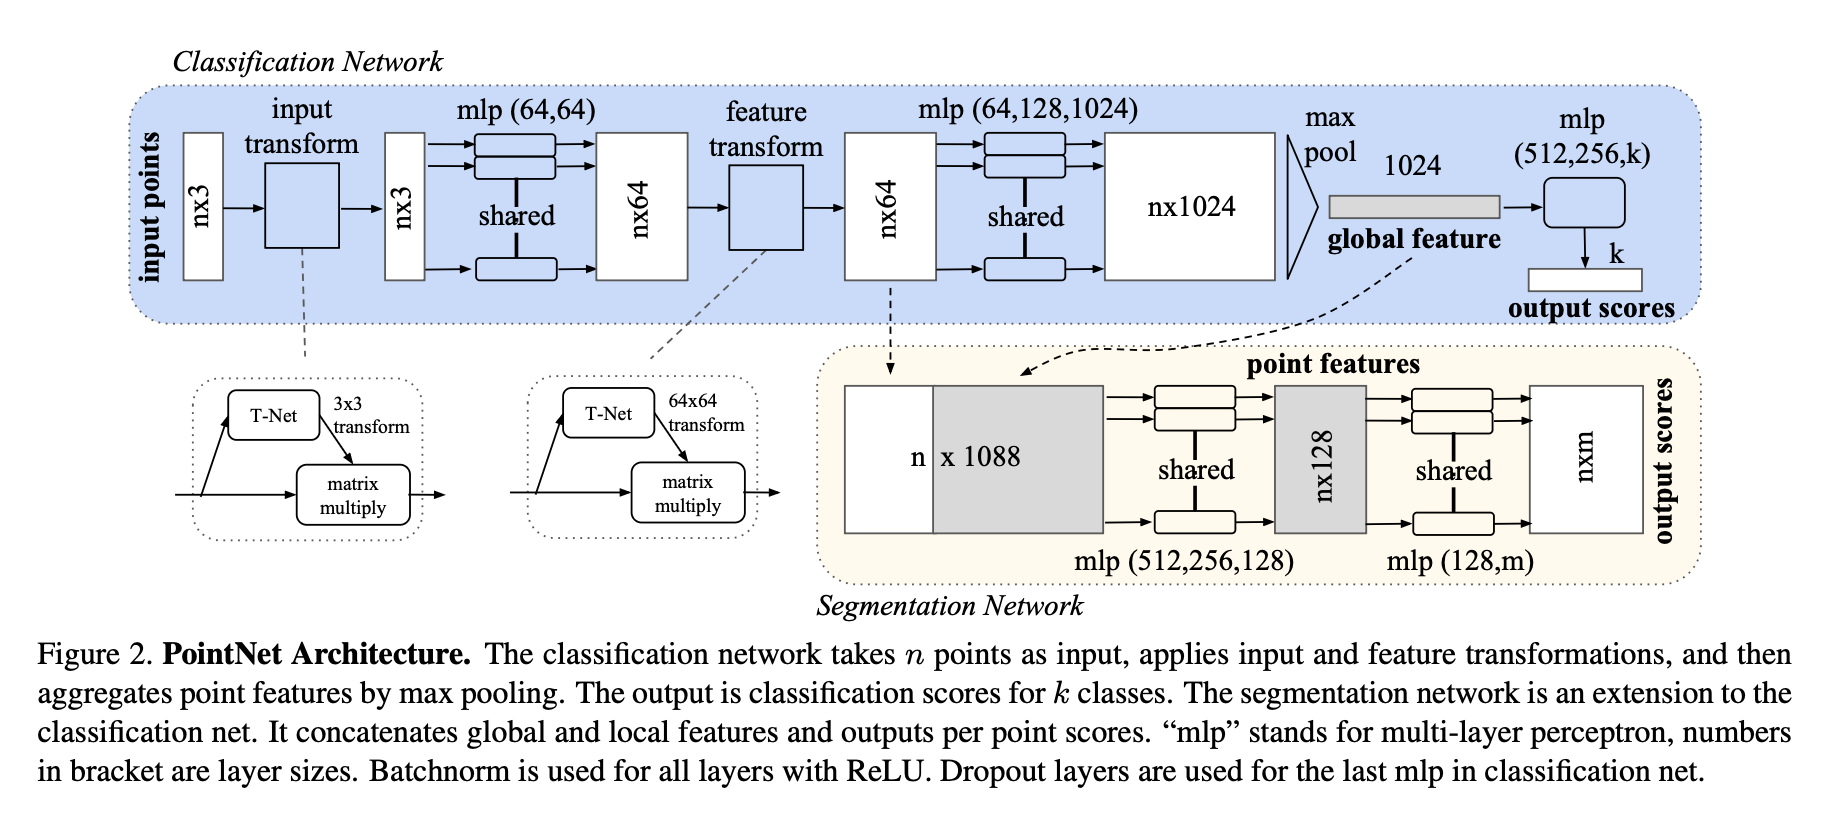

In [78]:
class TNet(nn.Module):
    """Layer inside the transform layers. Outputs a D*D matrix to multiply the input.``
    This is meant to rotate+scale the points to make it size/rotation invariant.
    Invertible matrix with the loss penalties.
    """
    def __init__(self, feature_count):
        super().__init__()
        self.feature_count = feature_count
        self.ff1 = nn.Linear(feature_count, 64)
        self.norm1 = PointBatchNorm(64)
        self.ff2 = nn.Linear(64, 128)
        self.norm2 = PointBatchNorm(128)
        self.ff3 = nn.Linear(128, 1024)
        self.norm3 = PointBatchNorm(1024)
        self.ff4 = nn.Linear(1024, 512)
        self.norm4 = PointBatchNorm(512)
        self.ff5 = nn.Linear(512, 256)
        self.norm5 = PointBatchNorm(256)
        self.ff6 = nn.Linear(256, feature_count * feature_count)
        xavier_init(self)
        nn.init.zeros_(self.ff6.weight)
        nn.init.zeros_(self.ff6.bias)

    def forward(self, x):
        # x : (B, T, N, D)
        batch_size, frame_count, _, _ = x.shape
        x = F.relu(self.norm1(self.ff1(x)))
        x = F.relu(self.norm2(self.ff2(x)))
        x = F.relu(self.norm3(self.ff3(x)))
        x = torch.max(x, dim=2)[0].unsqueeze(2) # max-reduction over N, keeps one point per feature
        x = F.relu(self.norm4(self.ff4(x)))
        x = F.relu(self.norm5(self.ff5(x)))
        x = self.ff6(x)  # last layer isn't normalized nor activated
        mat = x.view(batch_size, frame_count, self.feature_count, self.feature_count) # (B, T, D, D)
        eye = torch.eye(self.feature_count, device=x.device).unsqueeze(0).repeat(batch_size, frame_count, 1, 1)
        # T identity matrices, shape: (B, T, D, D)
        return mat + eye

In [79]:
class PointBatchNorm(nn.Module):
    "BatchNorm with one channel per feature; stats are over batch and points."
    def __init__(self, feature_count):
        super().__init__()
        self.norm = nn.BatchNorm1d(feature_count)

    def forward(self, x):
        if x.dim() == 2:
            return self.norm(x)

        batch_size, frame_count, point_count, feature_count = x.shape
        x = x.reshape(batch_size * frame_count * point_count, feature_count)
        x = self.norm(x)
        return x.view(batch_size, frame_count, point_count, feature_count)

In [80]:
def frequencies(feature_count, max_padding, theta = 1000):
    """Precompute the frequencies for all token positions in the sentence and
    for all pairs of features."""
    freqs = 1.0 / (theta ** (torch.arange(0, feature_count, 2) / feature_count))
    # the first feature pairs have high frequency, hence distance sensitive, the final pairs have low frequencies and are capture global properties
    t = torch.arange(max_padding)
    freqs = torch.outer(t, freqs).float() # all possible products
    return torch.cos(freqs), torch.sin(freqs)

def embed_positions(A, cos, sin):
    """Apply the rotation to q and k to embed token relative positions."""
    even_feature_count = A.size(-1) - A.size(-1) % 2
    if even_feature_count == 0:
        return A
    rotated = A[..., :even_feature_count]
    rest = A[..., even_feature_count:]
    cos, sin = (x[:A.size(-2), :even_feature_count // 2].to(A)[None, None, None].repeat_interleave(2, dim=-1) for x in (cos, sin))
    x1, x2 = rotated.chunk(2, dim=-1)
    rotated = rotated * cos + torch.cat((-x2, x1), dim=-1) * sin
    return torch.cat((rotated, rest), dim=-1) if rest.numel() else rotated

In [81]:
def attention(query, key, value, dropout):
    "Scaled dot product between query and key, and distribute the scores on value."
    # q, k, v: (B, H, N, T, D/H)
    d_k = query.size(-1)  # reduced space head_dimension 
    scores = torch.matmul(query, key.transpose(-2, -1)) / (d_k ** 0.5) # scores : (B, H, N, T, T)
    # divide by sqrt(d_k) to not reach softmax plateau where gradient is almost zero

    p_attn = scores.softmax(dim=-1) # probability of key answering query
    p_attn = dropout(p_attn) 
    return torch.matmul(p_attn, value) # (B, H, N, T, D/H)

In [82]:
class MultiHeadedAttention(nn.Module):
    """
    Multi-head attention module: projects into smaller dimension spaces 
    and then apply specialized attention in each of them.
    Here a point is updated with respect to the time dimension
    """

    def __init__(self, feature_count, frame_count, dropout_rate):
        super().__init__()
        head_amount = min(CONFIG['head_amount'], feature_count)
        while feature_count % head_amount != 0:
            head_amount -= 1
        self.head_dimension = feature_count // head_amount # smaller head space dimension
        self.head_amount = head_amount
        self.linears = nn.ModuleList([nn.Linear(feature_count, feature_count, bias=False) for _ in range(4)]) # Q, K, V, Out 
        self.dropout = nn.Dropout(dropout_rate)

        cos, sin = frequencies(self.head_dimension, frame_count)
        self.register_buffer("sin", sin) # to move them on DEVICE with the instance
        self.register_buffer("cos", cos)
        xavier_init(self)

    def forward(self, x):
        # x: (B, T, N, D)
        B, T, N, _ = x.size()
        query, key, value = [
            lin(x).view(B, T, N, self.head_amount, self.head_dimension).transpose(1, 3)
            for lin, x in zip(self.linears, (x, x, x)) 
        ] # q, k, v: (B, T, N, H, D/H) -> (B, H, N, T, D/H)

        query = embed_positions(query, self.cos, self.sin)
        key = embed_positions(key, self.cos, self.sin)
        x = attention(query, key, value, dropout=self.dropout) # (B, H, N, T, D/H)
        x = x.transpose(1, 3).reshape(B, T, N, self.head_amount * self.head_dimension) # (B, T, N, D)
        return self.linears[3](x) # apply final linear projection

In [83]:
class EncoderBlock(nn.Module):
    """Block of the main architecture contaning a TNet tranformed
    followed by a shared mlp, followed by an attention layer across time dimension."""

    def __init__(self, input_feature, mlp_dims):
        super().__init__()
        self.tnet = TNet(feature_count=input_feature)
        self.mlp_layers = nn.ModuleList()
        self.mlp_norms = nn.ModuleList()
        for in_dim, out_dim in zip(mlp_dims[:-1], mlp_dims[1:]):
            self.mlp_layers.append(nn.Linear(in_dim, out_dim))
            self.mlp_norms.append(PointBatchNorm(out_dim))
        self.attention = MultiHeadedAttention(input_feature, CONFIG['frame_count'], 0.1)
 
    def forward(self, x):
        # x: (B, T, N, D)
        self.trans_matrix = self.tnet(x) # (B, T, D, D)
        x = x @ self.trans_matrix # transform layer mutiplying the input by TNet matrix

        attention = self.attention(x)
        x = x + attention

        for linear, norm in zip(self.mlp_layers[:-1], self.mlp_norms[:-1]):
            x = F.relu(norm(linear(x)))
        x = self.mlp_norms[-1](self.mlp_layers[-1](x)) # last linear not followed by ReLU

        return x

In [84]:
class Generator(nn.Module):
    "Compute logits from the global features."
    def __init__(self, class_amount = len(ACTIVITY_CLASS_NAMES), dropout_rate=0.3):
        super().__init__()
        self.ff1 = nn.Linear(1024, 512)
        self.norm1 = PointBatchNorm(512)
        self.ff2 = nn.Linear(512, 256)
        self.norm2 = PointBatchNorm(256)
        self.ff3 = nn.Linear(256, class_amount)
        self.dropout = nn.Dropout(dropout_rate)  # 0.3 is the value used in the paper
        xavier_init(self)
    
    def forward(self, x):
        # x: (B, 1024)
        x = F.relu(self.norm1(self.ff1(x)))
        x = F.relu(self.norm2(self.ff2(x)))
        x = self.dropout(x)
        return self.ff3(x)

In [85]:
class PointNet(nn.Module):
    "The whole architecture"
    def __init__(self, feature_amount):
        super().__init__()
        self.block1 = EncoderBlock(feature_amount, [feature_amount, 64, 64])
        self.block2 = EncoderBlock(64, [64, 64, 128, 1024])
        self.generator = Generator()

    def forward(self, x):
        # x: (B, T, N, D)
        batch_size, frame_count, _, _ = x.shape
        x = self.block1(x) # x: (B, T, N, 64)
        x = self.block2(x) # x: (B, T, N, 1024)
        x = torch.max(x, dim=2)[0]  # maxpool over N
        x = x.view(batch_size, frame_count, 1024).mean(dim=1) # x: (B, 1024)
        logits = self.generator(x)
        return logits

In [ ]:
train_files, valid_files = split_train_val_file_paths()
train_samples = build_window_index(train_files)
valid_samples = build_window_index(valid_files)
print(f'Train windows: {len(train_samples)}')
print(f'Validation windows: {len(valid_samples)}')

In [87]:
model = PointNet(CONFIG["feature_amount"])

train_dataset = MARSDataset(train_samples)
train_dataloader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True)
sample_batch, sample_labels = next(iter(train_dataloader))
print(f'Input shape: {sample_batch.shape}') # x: (B, T, N, D)
print(f'Label shape: {sample_labels.shape}') 
output = model(sample_batch)
print(f'Output shape: {output.shape}')

Input shape: torch.Size([16, 60, 64, 5])
Label shape: torch.Size([16])
Output shape: torch.Size([16, 10])


# training

In [ ]:
def create_dataloaders(batch_size):
    "Create train and validation dataloaders."
    train_files, valid_files = split_train_val_file_paths()
    train_samples = build_window_index(train_files)
    valid_samples = build_window_index(valid_files)
    train_dataset = MARSDataset(train_samples)
    valid_dataset = MARSDataset(valid_samples)
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
    return train_dataloader, valid_dataloader

In [89]:
def rate(epoch, base, warmup=5):
    "Learning rate schedule."
    epoch = max(epoch, 1)
    return base * min(epoch ** (-0.5), epoch * warmup ** (-1.5))

In [90]:
def orthogonal(matrix):
    "Penalty term to make the TNet matrices more orthogonal."
    batch_size, frame_count, feature_count, _ = matrix.shape # matrix: (B, T, D, D)
    eye = torch.eye(feature_count, device=matrix.device).unsqueeze(0).repeat(batch_size, frame_count, 1, 1)
    diff = eye - matrix@matrix.transpose(-1,-2)
    return diff.pow(2).sum(dim=(-1, -2)).mean()

In [91]:
class SimpleLossCompute:
    "Loss compute helper matching run_epoch signature."
    def __init__(self, model, regul_coeff = 0.001):
        self.model = model
        self.regul_coeff = regul_coeff

    def __call__(self, out, targets, batch_size):
        loss_node = F.cross_entropy(out, targets) # negative log-likelihood loss
        reg1 = orthogonal(self.model.block1.trans_matrix)
        reg2 = orthogonal(self.model.block2.trans_matrix)
        loss_node = loss_node + self.regul_coeff * (reg1 + reg2)
        loss = loss_node.detach() * batch_size
        return loss, loss_node

In [92]:
def run_epoch(data_iter, model, loss_compute, optimizer=None, mode="train", accum_iter=1):
    "Runs one epoch, either for training, either validation."
    start = time.time()
    device = torch.device(DEVICE)
    total_tokens, total_loss, tokens, n_accum = 0, 0, 0, 0
    loss_list, grad_norms = [], []

    for i, batch in enumerate(data_iter):
        src, targets = batch
        src = src.to(device)
        targets = targets.to(device)
        ntokens = targets.size(0)

        out = model.forward(src)
        loss, loss_node = loss_compute(out, targets, ntokens)

        if mode == "train":
            (loss_node / accum_iter).backward()
            if i % accum_iter == 0:
                if optimizer is not None:
                    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), float("inf"))
                    grad_norms.append(norm.item())
                    optimizer.step()
                    optimizer.zero_grad(set_to_none=True)
                n_accum += 1

        total_loss += loss
        total_tokens += ntokens
        tokens += ntokens
        loss_list.append((loss / ntokens).item())

        if i % 40 == 1 and (mode == "train"):
            lr = optimizer.param_groups[0]["lr"]
            elapsed = time.time() - start
            print(
                ("Batch: %6d | Accum. Step: %3d | Loss: %6.2f " + "| Samples/sec: %7.1f | Learn. Rate: %6.1e")
                % (i, n_accum, loss / ntokens, tokens / elapsed, lr)
            )
            start = time.time()
            tokens = 0

    return loss_list, grad_norms

In [93]:
def plot(train_losses, valid_losses, all_grad_norms, model_param_count, num_epochs, train_epoch_sizes, valid_epoch_sizes, epoch_means):
    "Plot the losses and the gradient norm over the training process."
    x_train = [e + i / s for e, s in enumerate(train_epoch_sizes) for i in range(s)]
    x_valid = [e + i / s for e, s in enumerate(valid_epoch_sizes) for i in range(s)]
    epoch_mean_valid_losses = [m for s, m in zip(valid_epoch_sizes, epoch_means) for _ in range(s)]

    plt.figure(figsize=(10, 10))
    ax1 = plt.subplot(2, 1, 1)
    w = max(1, int((len(train_losses) / num_epochs) * 0.1))
    train_loss_rolling = pd.Series(train_losses).rolling(window=w, center=True).mean()
    plt.plot(x_train, train_losses, label="Training Loss"); plt.plot(x_train, train_loss_rolling, label="Training Loss (Avg)", color="darkblue", linewidth=1); plt.plot(x_valid, valid_losses, label="Validation Loss", alpha=0.7); plt.plot(x_valid, epoch_mean_valid_losses, label="Val Loss (Avg)", color="red", linewidth=1, linestyle="--")
    plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.title("Training and Validation Loss Over Epochs")
    ax1.set_xlim(0, num_epochs); ax1.set_xticks(range(num_epochs + 1))
    loss_values = pd.Series(train_losses + valid_losses + epoch_means).dropna()
    q1, q3 = loss_values.quantile(0.25), loss_values.quantile(0.75)
    bottom, top = max(0, q1 - 1.5 * (q3 - q1)), q3 + 1.5 * (q3 - q1)
    if top < loss_values.max(): ax1.set_ylim(bottom, top + max((top - bottom) * 0.05, 1e-6))
    y_min, y_max = ax1.get_ylim()
    best_mean_val = float("inf")
    for i, mean_val in enumerate(epoch_means):
        if mean_val <= best_mean_val and y_min <= mean_val <= y_max: ax1.text(i + 0.5, mean_val, f"{mean_val:.3g}", color="red", ha="center", va="bottom", fontweight="medium", clip_on=True)
        best_mean_val = min(best_mean_val, mean_val)

    ax = plt.subplot(2, 1, 2)
    plt.plot(x_train, all_grad_norms, label="Gradient Norm", color="orange"); plt.xlabel("Epochs"); plt.ylabel("Norm"); plt.legend(); plt.title("Gradient Norm over Epochs")
    ax.set_xlim(0, num_epochs); ax.set_xticks(range(num_epochs + 1))
    grad_values = pd.Series(all_grad_norms).dropna()
    q1, q3 = grad_values.quantile(0.25), grad_values.quantile(0.75)
    bottom, top = max(0, q1 - 1.5 * (q3 - q1)), q3 + 1.5 * (q3 - q1)
    if top < grad_values.max(): ax.set_ylim(bottom, top + max((top - bottom) * 0.05, 1e-6))
    ax.text(0.99, 0.02, f"Params count: {model_param_count:,}", transform=ax.transAxes, ha="right", va="bottom", fontsize=9, color="dimgray")

    plt.subplots_adjust(hspace=0.35); plt.show()

In [95]:
def train_model(num_epochs=CONFIG["num_epochs"]):
    "Launch the training process of a model."
    print("Training process starting...", flush=True)
    model = PointNet(CONFIG["feature_amount"])
    device = torch.device(DEVICE)
    model.to(device)
    model_param_count = sum(p.numel() for p in model.parameters())

    train_dataloader, valid_dataloader = create_dataloaders(batch_size=CONFIG["batch_size"])
    initial_lr = rate(1, CONFIG["base_lr"], CONFIG["lr_warmup_epochs"])
    optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr, betas=(CONFIG["adam_momentum"], 0.999))

    train_losses, valid_losses, all_grad_norms = [], [], []
    train_epoch_sizes, valid_epoch_sizes, epoch_means = [], [], []
    loss_compute = SimpleLossCompute(model)
    checkpoint_dir = CHECKPOINT_ROOT
    checkpoint_dir.mkdir(exist_ok=True)

    for epoch in range(num_epochs):
        epoch_lr = rate(epoch + 1, CONFIG["base_lr"], CONFIG["lr_warmup_epochs"])
        for param_group in optimizer.param_groups:
            param_group["lr"] = epoch_lr
        model.train()
        print(f"Epoch n°{epoch} Training ====", flush=True)
        loss_list, grad_norms = run_epoch(
            train_dataloader,
            model,
            loss_compute,
            optimizer,
            mode="train",
            accum_iter=CONFIG["accum_iter"],
        )
        train_losses.extend(loss_list)
        train_epoch_sizes.append(len(loss_list))
        all_grad_norms.extend(grad_norms)

        file_path = checkpoint_dir / f"checkpoint_{epoch:02d}.pt"
        torch.save(model.state_dict(), file_path)

        print(f"Epoch n°{epoch} Validation ====", flush=True)
        model.eval()
        with torch.no_grad():
            loss_list, _ = run_epoch(valid_dataloader, model, loss_compute, None, mode="eval")
        valid_losses.extend(loss_list)
        valid_epoch_sizes.append(len(loss_list))

        mean_val = sum(loss_list) / len(loss_list)
        epoch_means.append(mean_val)
        clear_output(wait=True)
        print("Training process starting...", flush=True)
        print(f"Epoch n°{epoch} complete | Validation loss: {mean_val:.4f}", flush=True)
        plot(train_losses, valid_losses, all_grad_norms, model_param_count, num_epochs, train_epoch_sizes, valid_epoch_sizes, epoch_means)

    return model

Training process starting...
Epoch n°19 complete | Validation loss: 0.2604


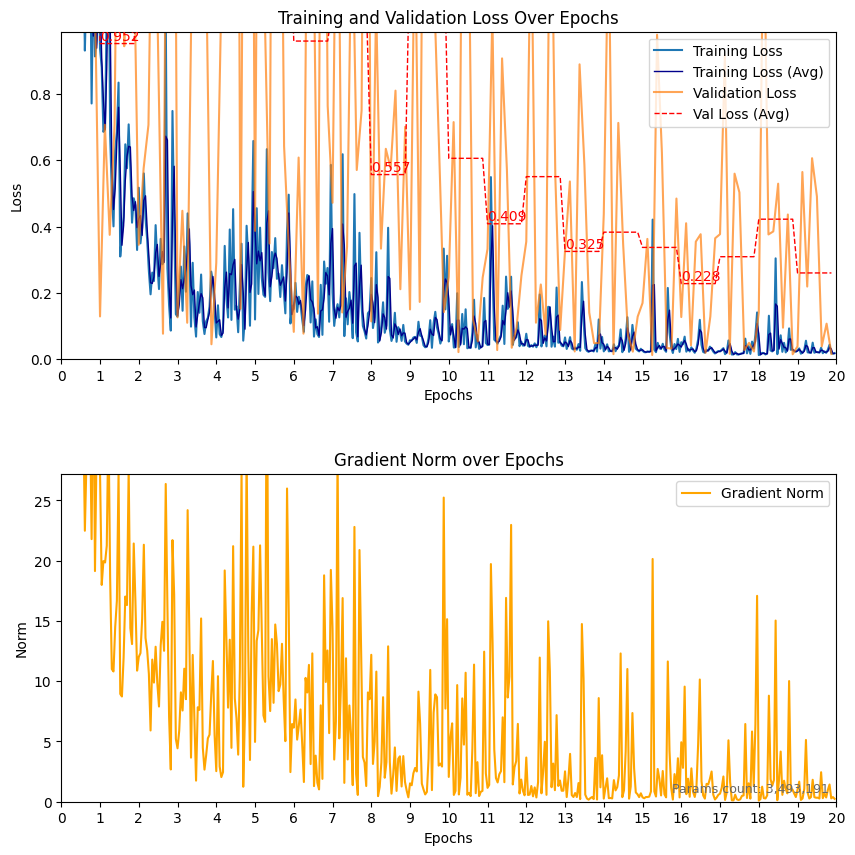

In [ ]:
if __name__ == "__main__":
    train_model(30)

# inference

In [97]:
def compute_macro_f1(predictions, labels):
    scores = []
    for class_idx in range(len(ACTIVITY_CLASS_NAMES)):
        true_positive = ((predictions == class_idx) & (labels == class_idx)).sum().item()
        false_positive = ((predictions == class_idx) & (labels != class_idx)).sum().item()
        false_negative = ((predictions != class_idx) & (labels == class_idx)).sum().item()
        denominator = 2 * true_positive + false_positive + false_negative
        scores.append(0.0 if denominator == 0 else 2 * true_positive / denominator)
    return torch.tensor(scores, dtype=torch.float32)

In [98]:
def compute_accuracy(predictions, labels):
    return (predictions == labels).float().mean().item()

In [ ]:
def evaluate_validation_checkpoint(checkpoint_path):
    "Score a checkpoint on validation only."
    device = torch.device(DEVICE)
    model = PointNet(CONFIG['feature_amount']).to(device)
    state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()

    _, valid_files = split_train_val_file_paths()
    eval_samples = build_window_index(valid_files)
    eval_dataset = MARSDataset(eval_samples)
    eval_loader = DataLoader(eval_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

    all_predictions = []
    all_labels = []
    with torch.no_grad():
        for batch, labels in eval_loader:
            logits = model(batch.to(device))
            all_predictions.append(logits.argmax(dim=1).cpu())
            all_labels.append(labels.cpu())

    predictions = torch.cat(all_predictions)
    labels = torch.cat(all_labels)
    per_class_f1 = compute_macro_f1(predictions, labels)
    macro_f1 = per_class_f1.mean().item()
    accuracy = compute_accuracy(predictions, labels)
    return macro_f1, {name: float(score) for name, score in zip(ACTIVITY_CLASS_NAMES, per_class_f1)}, accuracy

In [ ]:
checkpoint_path = CHECKPOINT_ROOT / "checkpoint_18.pt"
macro_f1, per_class_f1, accuracy = evaluate_validation_checkpoint(checkpoint_path)
print(f'Macro F1: {macro_f1:.4f}')
print(f'Accuracy: {accuracy:.4f}')
print(per_class_f1)

In [ ]:
checkpoint_path = CHECKPOINT_ROOT / "checkpoint_06.pt"
macro_f1, per_class_f1, accuracy = evaluate_validation_checkpoint(checkpoint_path)
print(f'Macro F1: {macro_f1:.4f}')
print(f'Accuracy: {accuracy:.4f}')
print(per_class_f1)

In [ ]:
checkpoint_paths = sorted(CHECKPOINT_ROOT.glob("checkpoint_*.pt"), key=lambda path: int(path.stem.split("_")[-1]))
metrics = [evaluate_validation_checkpoint(path) for path in checkpoint_paths]
checkpoint_labels = [path.stem for path in checkpoint_paths]
macro_f1_scores = [metric[0] for metric in metrics]
accuracy_scores = [metric[2] for metric in metrics]

plt.figure(figsize=(10, 5))
macro_line, = plt.plot(checkpoint_labels, macro_f1_scores, marker="o", label="Macro F1")
accuracy_line, = plt.plot(checkpoint_labels, accuracy_scores, marker="o", label="Accuracy")

best_macro_f1 = -1
for idx, score in enumerate(macro_f1_scores):
    if score > best_macro_f1:
        plt.text(idx, score + 0.02, f"{score:.3f}", ha="center", color=macro_line.get_color())
        best_macro_f1 = score

best_accuracy = -1
for idx, score in enumerate(accuracy_scores):
    if score > best_accuracy:
        plt.text(idx, score + 0.05, f"{score:.3f}", ha="center", color=accuracy_line.get_color())
        best_accuracy = score

plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.ylabel("Score")
plt.title("Validation checkpoint performance")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
best_idx = max(range(len(accuracy_scores)), key=lambda idx: accuracy_scores[idx])
best_checkpoint_path = checkpoint_paths[best_idx]
device = torch.device(DEVICE)
model = PointNet(CONFIG['feature_amount']).to(device)
state_dict = torch.load(best_checkpoint_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

eval_samples = build_window_index(test_file_paths())
eval_dataset = MARSDataset(eval_samples)
eval_loader = DataLoader(eval_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

all_predictions = []
all_labels = []
with torch.no_grad():
    for batch, labels in eval_loader:
        logits = model(batch.to(device))
        all_predictions.append(logits.argmax(dim=1).cpu())
        all_labels.append(labels.cpu())

predictions = torch.cat(all_predictions)
labels = torch.cat(all_labels)
per_class_f1 = compute_macro_f1(predictions, labels)
test_macro_f1 = per_class_f1.mean().item()
test_accuracy = compute_accuracy(predictions, labels)
print(f'Best validation checkpoint: {best_checkpoint_path.name}')
print(f'Validation accuracy: {accuracy_scores[best_idx]:.4f}')
print(f'Test macro F1: {test_macro_f1:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')
print({name: float(score) for name, score in zip(ACTIVITY_CLASS_NAMES, per_class_f1)})